In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Imputation Modules
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# Machine Learning Modules
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

=== Class Distribution (is_good_credit) ===
is_good_credit
1    50.13%
0    49.87%
Name: proportion, dtype: str

1. Data Prepared. Targets for Missing Injection: ['education_level', 'employment_status', 'monthly_income_usd', 'age', 'job_title']

--------------------------------------------------
🔄 Processing Missing Rate: 10%
--------------------------------------------------

--------------------------------------------------
🔄 Processing Missing Rate: 20%
--------------------------------------------------

--------------------------------------------------
🔄 Processing Missing Rate: 30%
--------------------------------------------------

--------------------------------------------------
🔄 Processing Missing Rate: 40%
--------------------------------------------------

--------------------------------------------------
🔄 Processing Missing Rate: 50%
--------------------------------------------------

=== Downstream ML Performance Comparison (F1-Score) ===


Missing Rate                                            10%     20%     30%  \
ML Model            Dataset Version                                           
Logistic Regression 1. Ground Truth (No Missing)     0.5126  0.5126  0.5126   
                    2. Simple Imputed (Mode/Median)  0.5031  0.4897  0.5102   
                    3. KNN Imputed                   0.5089  0.5055  0.5053   
                    4. Iterative Imputed             0.4899  0.4640  0.4868   
Naive Bayes         1. Ground Truth (No Missing)     0.4442  0.4442  0.4442   
                    2. Simple Imputed (Mode/Median)  0.4551  0.4448  0.4462   
                    3. KNN Imputed                   0.4930  0.4363  0.4663   
                    4. Iterative Imputed             0.2208  0.2507  0.1925   
Random Forest       1. Ground Truth (No Missing)     0.4835  0.4835  0.4835   
                    2. Simple Imputed (Mode/Median)  0.4871  0.4817  0.4889   
                    3. KNN Imputed                   0.4997  0.5004  0.5236   
                    4. Iterative Imputed             0.5177  0.5323  0.5412   

Missing Rate                                            40%     50%  
ML Model            Dataset Version                                  
Logistic Regression 1. Ground Truth (No Missing)     0.5126  0.5126  
                    2. Simple Imputed (Mode/Median)  0.5077  0.5121  
                    3. KNN Imputed                   0.5052  0.5077  
                    4. Iterative Imputed             0.5083  0.5164  
Naive Bayes         1. Ground Truth (No Missing)     0.4442  0.4442  
                    2. Simple Imputed (Mode/Median)  0.4459  0.4332  
                    3. KNN Imputed                   0.4497  0.4852  
                    4. Iterative Imputed             0.0086  0.0086  
Random Forest       1. Ground Truth (No Missing)     0.4835  0.4835  
                    2. Simple Imputed (Mode/Median)  0.4984  0.5010  
                    3. KNN Imputed                   0.5243  0.5578  
                    4. Iterative Imputed             0.4858  0.4964

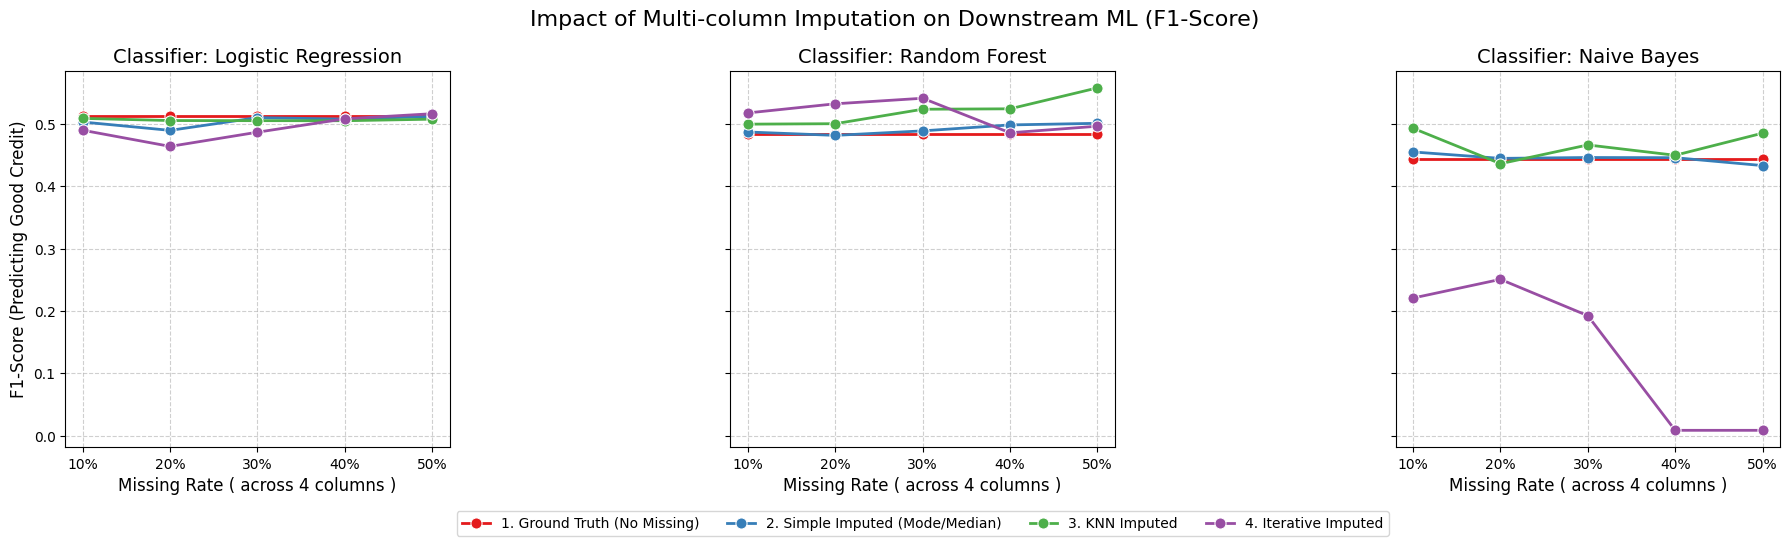

In [2]:
# ==========================================
# 1. Collect Data & Clean Data
# ==========================================
df = pd.read_csv('data/synthetic_personal_finance_dataset.csv')

# ตัดคอลัมน์ที่ไม่จำเป็น
df_clean = df.drop(columns=['user_id', 'record_date']).copy()

# สร้าง Downstream Target
df_clean['is_good_credit'] = (df_clean['credit_score'] >= 575).astype(int)

print("=== Class Distribution (is_good_credit) ===")
print(df_clean['is_good_credit'].value_counts(normalize=True).apply(lambda x: f"{x:.2%}"))
print("===========================================\n")

# ตัด credit_score เดิมทิ้ง
df_clean = df_clean.drop(columns=['credit_score'])

# [NEW] กำหนดเป้าหมายให้เจาะรูข้อมูลหลายๆ คอลัมน์ (ผสมทั้ง Categorical และ Numerical)
impute_targets = ['education_level', 'employment_status', 'monthly_income_usd', 'age', 'job_title']
missing_rates = [0.1, 0.2, 0.3, 0.4, 0.5] 

print(f"1. Data Prepared. Targets for Missing Injection: {impute_targets}")

# ==========================================
# กำหนด ML Models และ ฟังก์ชันสำหรับเตรียม Train/Test
# ==========================================
ml_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Naive Bayes': GaussianNB() 
}

def prep_for_ml(df_input):
    df_ml = df_input.copy()
    X = df_ml.drop(columns=['is_good_credit'])
    y = df_ml['is_good_credit']
    X = pd.get_dummies(X, drop_first=True)
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

results = []

# ==========================================
# เริ่ม Loop ทดสอบทีละ Missing Rate (10% - 50%)
# ==========================================
for rate in missing_rates:
    rate_str = f"{int(rate*100)}%"
    print(f"\n{'-'*50}")
    print(f"🔄 Processing Missing Rate: {rate_str}")
    print(f"{'-'*50}")
    
    # 2. Multi-column Missing Injection
    np.random.seed(42)
    df_simulated = df_clean.copy()
    
    for col in impute_targets:
        n_missing = int(len(df_clean) * rate)
        missing_indices = np.random.choice(df_clean.index, n_missing, replace=False)
        df_simulated.loc[missing_indices, col] = np.nan

    # 3. Impute Data
    df_for_impute = df_simulated.copy()
    le_dict = {}
    cat_cols = df_for_impute.select_dtypes(include=['object', 'string']).columns

    # 3.0 Encode Categorical -> Float
    for col in cat_cols:
        le = LabelEncoder()
        # Fit with existing + placeholder for safety
        non_null_vals = df_for_impute[col].dropna().astype(str).tolist()
        le.fit(non_null_vals + ['Missing_Fallback']) 
        le_dict[col] = le
        
        not_null_mask = df_for_impute[col].notnull()
        encoded_col = pd.Series(np.nan, index=df_for_impute.index, dtype=float)
        encoded_col.loc[not_null_mask] = le.transform(df_for_impute.loc[not_null_mask, col].astype(str))
        df_for_impute[col] = encoded_col

    # 3.0 Scale ALL columns (สำคัญมากเมื่อทำ Multi-column imputation เพื่อหาระยะห่างที่ยุติธรรม)
    scaler_impute = StandardScaler()
    col_names = df_for_impute.columns
    df_for_impute_scaled = pd.DataFrame(scaler_impute.fit_transform(df_for_impute), columns=col_names, index=df_for_impute.index)

    # --- 3.1 Simple Imputed (Mode for Cat, Median for Num) ---
    df_simple = df_simulated.copy()
    for col in impute_targets:
        if col in cat_cols:
            mode_val = df_simple[col].mode()[0]
            df_simple[col] = df_simple[col].fillna(mode_val)
        else:
            median_val = df_simple[col].median()
            df_simple[col] = df_simple[col].fillna(median_val)

    # --- 3.2 KNN Imputed ---
    knn_imputer = KNNImputer(n_neighbors=5)
    df_knn_scaled = pd.DataFrame(knn_imputer.fit_transform(df_for_impute_scaled), columns=col_names, index=df_for_impute.index)
    # Inverse Scale กลับเป็นตัวเลขขนาดปกติ
    df_knn_num = pd.DataFrame(scaler_impute.inverse_transform(df_knn_scaled), columns=col_names, index=df_for_impute.index)

    # --- 3.3 Iterative Imputed ---
    iter_imputer = IterativeImputer(estimator=BayesianRidge(), random_state=42, max_iter=10)
    df_iter_scaled = pd.DataFrame(iter_imputer.fit_transform(df_for_impute_scaled), columns=col_names, index=df_for_impute.index)
    # Inverse Scale กลับเป็นตัวเลขขนาดปกติ
    df_iter_num = pd.DataFrame(scaler_impute.inverse_transform(df_iter_scaled), columns=col_names, index=df_for_impute.index)

    # --- นำค่าที่ซ่อมแล้ว ประกอบร่างกลับคืน ---
    df_knn = df_simulated.copy()
    df_iter = df_simulated.copy()
    
    for col in impute_targets:
        missing_mask = df_simulated[col].isnull()
        
        if col in cat_cols:
            # แปลงตัวเลขกลับเป็น Text สำหรับ Categorical
            imputed_knn_vals = np.round(df_knn_num.loc[missing_mask, col]).astype(int)
            imputed_knn_vals = np.clip(imputed_knn_vals, 0, len(le_dict[col].classes_) - 1)
            df_knn.loc[missing_mask, col] = le_dict[col].inverse_transform(imputed_knn_vals)
            
            imputed_iter_vals = np.round(df_iter_num.loc[missing_mask, col]).astype(int)
            imputed_iter_vals = np.clip(imputed_iter_vals, 0, len(le_dict[col].classes_) - 1)
            df_iter.loc[missing_mask, col] = le_dict[col].inverse_transform(imputed_iter_vals)
        else:
            # ดึงค่าตัวเลขมาใส่ตรงๆ สำหรับ Numerical
            df_knn.loc[missing_mask, col] = df_knn_num.loc[missing_mask, col]
            df_iter.loc[missing_mask, col] = df_iter_num.loc[missing_mask, col]

    datasets = {
        '1. Ground Truth (No Missing)': df_clean,
        '2. Simple Imputed (Mode/Median)': df_simple,
        '3. KNN Imputed': df_knn,
        '4. Iterative Imputed': df_iter
    }

    # 4 & 5. Evaluate with ML
    for data_name, df_data in datasets.items():
        X_train, X_test, y_train, y_test = prep_for_ml(df_data)
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        for model_name, model in ml_models.items():
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            
            results.append({
                'Missing Rate': rate_str,
                'Dataset Version': data_name,
                'ML Model': model_name,
                'Accuracy': acc,
                'Precision': prec,
                'Recall': rec,
                'F1-Score': f1
            })

# ==========================================
# 6. สรุปผลลัพธ์และพล็อตจุดกราฟ (Plotting)
# ==========================================
df_results = pd.DataFrame(results)

print("\n=== Downstream ML Performance Comparison (F1-Score) ===")
pivot_f1 = df_results.pivot_table(
    index=['ML Model', 'Dataset Version'], 
    columns='Missing Rate', 
    values='F1-Score'
)
display(pivot_f1.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Impact of Multi-column Imputation on Downstream ML (F1-Score)', fontsize=16)

for i, model_name in enumerate(ml_models.keys()):
    sns.lineplot(
        data=df_results[df_results['ML Model'] == model_name],
        x='Missing Rate', 
        y='F1-Score', 
        hue='Dataset Version', 
        marker='o', 
        linewidth=2,
        markersize=8,
        ax=axes[i], 
        palette='Set1'
    )
    axes[i].set_title(f'Classifier: {model_name}', fontsize=14)
    axes[i].set_xlabel('Missing Rate ( across 4 columns )', fontsize=12)
    axes[i].set_ylabel('F1-Score (Predicting Good Credit)', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)
    
    if i == 1:
        axes[i].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)
    else:
        axes[i].get_legend().remove()

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()